In [44]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal, Annotated
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
from dotenv import load_dotenv
from pydantic import BaseModel, Field
import operator

In [45]:
load_dotenv()

True

In [46]:
# in a real project, various LLMs are required as each LLM has its own speciality

generator_llm = ChatOpenAI(model='gpt-4o-mini')
evaluator_llm = ChatOpenAI(model='gpt-4o')
optimizer_llm = ChatOpenAI(model='gpt-4o-mini')

In [47]:
class EvalSchema(BaseModel):
    
    evaluation: Literal['Approved', 'Not_Approved'] = Field(description='Final evaluation of tweet')
    feedback: str = Field(description='Feedback for the tweet')

In [48]:
structured_evaluator_llm = evaluator_llm.with_structured_output(EvalSchema)

In [49]:
class PostState(TypedDict):

    topic: str
    tweet: str
    evaluation: Literal['Approved', 'Not_Approved']
    feedback: str
    iteration: int       #to find the number of iterations in the loop
    max_iteration: int       #number of iterations allowed to stop the loop in case of infinite loop

    tweet_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]

In [50]:
def generate_tweet(state: PostState):

    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english
""")
    ]

    response = generator_llm.invoke(messages).content

    return {'tweet': response, 'tweet_history': [response]}

In [51]:
def evaluate_tweet(state: PostState):

    messages = [
        SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor,originality, virality, and tweet format."), 
        HumanMessage(content=f"""
    Evaluate the following tweet:
                     
    Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality - Is this fresh, or have you seen it a hundred times before?
2. Humor - Did it genuinely make you smile, laugh, or chuckle?
3. Punchiness - Is it short, sharp, and scroll-stopping?
4. Virality - Potential Would people retweet or share it?
5. Format - Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:

- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., "Masterpieces of the auntie-uncle universe" or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"
- feedback: One paragraph explaining the strengths and weaknesses
""")
    ]

    response = structured_evaluator_llm.invoke(messages)

    return {'evaluation': response.evaluation, 'feedback': response.feedback, 'feedback_history': [response.feedback]}

In [52]:
def optimize_tweet(state: PostState):
    
    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]

    response = optimizer_llm.invoke(messages).content
    iteration = state['iteration'] + 1

    return {'tweet': response, 'iteration': iteration, 'tweet_history': [response]}

In [53]:
def route_evaluation(state: PostState):

    if state['evaluation'] == 'Approved' or state['iteration'] >= state['max_iteration']:
        return 'Approved'
    else:
        return 'Not_Approved'

In [54]:
graph = StateGraph(PostState)

graph.add_node('Generate', generate_tweet)
graph.add_node('Evaluate', evaluate_tweet)
graph.add_node('Optimize', optimize_tweet)

graph.add_edge(START, 'Generate')
graph.add_edge('Generate', 'Evaluate')

graph.add_conditional_edges('Evaluate', route_evaluation, {'Approved': END, 'Not_Approved': 'Optimize'})
graph.add_edge('Optimize', 'Evaluate')

workflow = graph.compile()

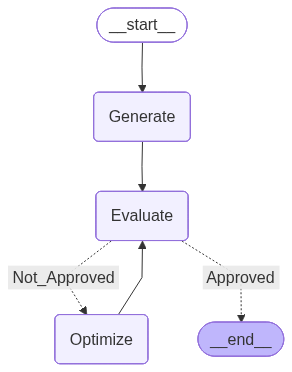

In [55]:
workflow

In [56]:
initial_state = {
    "topic": "Indian Railways",
    "iteration": 1,
    "max_iteration": 5
}

workflow.invoke(initial_state)

{'topic': 'Indian Railways',
 'tweet': 'Indian Railways: where your journey includes summer in the waiting room, a monsoon bath in the aisle, winter in the toilets, and spring—when the snack vendor magically appears. Forget a ticket, just bring your sense of adventure! 🚂🍿 #IndianRailways',
 'evaluation': 'Approved',
 'feedback': "This tweet about Indian Railways is both original and humorous, capturing the chaotic yet charming experience of train travel in India. The use of seasons to describe different aspects of the journey is a fresh angle, cleverly reflecting the diverse conditions and amusing quirks of railway travel. The humor is subtle yet effective, likely to resonate with anyone familiar with the experience, thus contributing to its virality potential. The tweet's format is well-crafted, fitting within the character limit and avoiding the pitfalls of a setup-punchline structure. Overall, it's an engaging tweet that successfully uses relatable humor and vivid imagery to capture